# The Vavilov Ice Cap surge, inversion on n and the half-width
Following the simple model, we devolped a more complex inversion to find the stress exponent and the half-width that produce the velocity profile model that best fit the data.

## Import packages
Use pgdal env

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from skimage.measure import profile_line
from scipy import ndimage
import matplotlib.gridspec as gridspec

#%matplotlib inline

## Functions

In [4]:
def ice_velocity(u_0, y, w, n, option=0):
    '''
    Calculate the transect velocity knowing the centrale velocity of the profile 
    u_0    --> velocity at the centrer of the profile (at y = 0) 
    y      --> Y vector position along a profile perpendicular to the flow, y = 0 at the center
    w      --> half-width of the profile
    n      --> stress exponent (see Glen's flow law)
    option --> 0 for y = 0 a center, 1 for y = 0 at margin
    '''
    if option == 0:
        u = (1 - (abs(y)/w) ** (n+1)) * u_0
    elif option == 1:
        u = (1 - (abs(1 - y/w)) ** (n+1)) * u_0
    return u

def setup_data(u, x1, x2):
    '''
    Set up needed data for the estimate of velocity
    u_0      --> velocity at the centerline of the profil (y = 0)
    w_model  --> half-width of the model
    y_model  --> Y vector position along a profile perpendicular to the flow, y = 0 at the center
    '''
    u_0 = np.max(u)
    w_model = (-x1+x2)/2
    y_model = np.linspace(-w_model,w_model,int(w_model*2))
    return u_0, y_model, w_model

def moving_avg(data, win_size):
    '''
    Calculate moving average
    data      --> data vector on which you estimate the average
    win_size  --> length of the moving window
    '''
    i = 0
    moving_averages = []
    while i < len(data) - win_size + 1:
        window = data[i : i + win_size]  #select the window
        window_average = round(sum(window) / win_size, 2)  #calculate the mean
        moving_averages.append(window_average)  #fill the new data vector
        i += 1
    return moving_averages


def flow_limits(u, win):
    '''
    Find limits of the flowing ice
    usmooth     --> smoothed version of the velocity profile by averaged moving windows
    ugrad       --> gradient of the smoothed velocity profile to find the fast-flow limits
    idx1, idx2  --> index of the flow limits
    '''
    usmooth = moving_avg(u,win)
    ugrad = np.diff(usmooth)
    idx1 = np.argmax(ugrad)
    idx2 = np.argmin(ugrad)
    return round(idx1), round(idx2)

def L1_norm_residuals(data, model, error):
    '''
    Calculate L1-norm (Manhattan geometry) between data and model
    '''
    curve = data - model / error ** 2
    res = np.nansum(curve) / len(data)
    return res

def L2_norm_residuals(data, model, variance):
    '''
    Calculate L2-norm (Euclidean distance) between data and model
    '''
    # Calculate the misfit with weights (variance)
    weighted_residuals = (data - model) ** 2 / variance
    misfit = np.sqrt(np.nansum(weighted_residuals) / len(data))
    return misfit

def variance_reduction(data, model):
    '''
    Calculate variance reduction
    '''
    res = (data - model) ** 2
    vr = np.sqrt(np.nansum(res)) / np.sqrt(np.nansum(data **2))
    #vr = 1 - (np.nansum(res)/np.nansum(data **2)) to test maybe?
    return vr

def prc_best_model(res, x_list, y_list, prc = 5):
    '''
    Evaluate the x% best models
    '''
    nb10 = round(res.size * prc / 100)                     # Estimate number of couple
    res_list = res.flatten()                               # Convert matrix into vector
    res_sorted = np.sort(res_list)                         # Sort residuals by increasing order
    best_res = res_sorted[0:nb10]                          # Identify the x% with the lowest residuals
    best_couple = []
    r = 0
    while r < nb10:                                  # Loop on number of best couple
        idx = np.argwhere(res == best_res[r])        # Find idx of best couple of parameters
        for i in range(int(np.size(idx)/2)):
            idx1, idx2 = idx[i,0], idx[i,1]
            best_couple.append([idx1, idx2])
        r += int(np.size(idx)/2)

    best_couple = np.array(best_couple)
    idx_x = best_couple[:,0]                               # list of the best x index
    idx_y = best_couple[:,1]                               # list of the best y index
    best_x = x_list[idx_x.astype('int')]                   # list of corresponding best x
    best_y = y_list[idx_y.astype('int')]                   # list of corresponding best y

    return best_x, best_y, idx_x, idx_y

## Load data: annual velocity fields from 2015 to 2018
We estimated those yearly averaged velocity images on QGIS (Raster Analysis > Cell Statistics > Median). We then need to download all the raster geotiff images to extract velocity profiles.

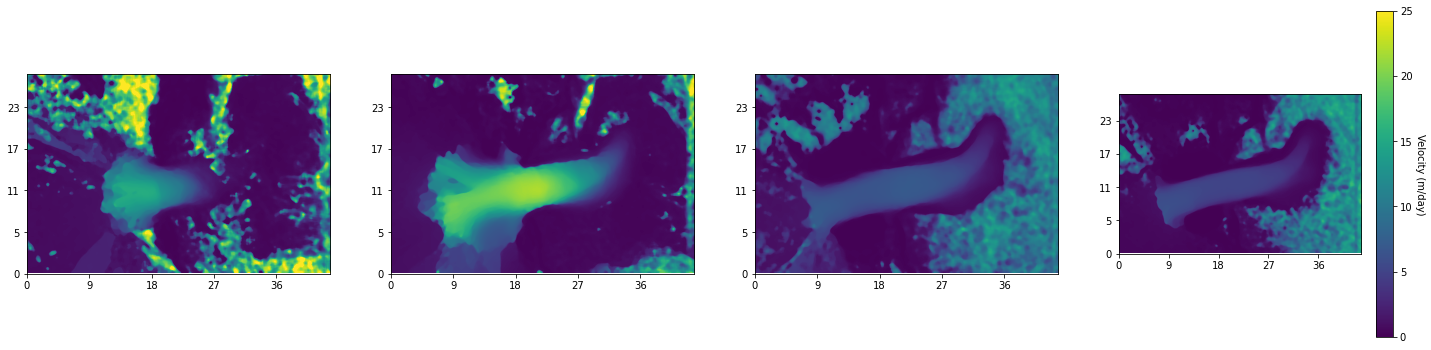

In [7]:
# Load all the velocity field files
save_fig = False
path_fig = '/Users/mouchonc/Documents/RESEARCH/IceRheology/figures/models/'
path = '/Users/mouchonc/Documents/RESEARCH/IceRheology/velocities/'
years_list = [2015, 2016, 2017, 2018]

img15 = rasterio.open(path + 'median_2015_cleaned2.tif')
img16 = rasterio.open(path + 'median_2016_cleaned2.tif')
img17 = rasterio.open(path + 'median_2017.tif')
img18 = rasterio.open(path + 'median_2018.tif')

# Median-filter images to remove edge peaks (20 pixel filter)
img15_filt = ndimage.median_filter(img15.read(1), 20)
img16_filt = ndimage.median_filter(img16.read(1), 20)
img17_filt = ndimage.median_filter(img17.read(1), 20)
img18_filt = ndimage.median_filter(img18.read(1), 20)

# Plot annual velocity fields
plt.figure(figsize=(25,6))
ax1 = plt.subplot(141)
plt.imshow(img15_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
ax2 = plt.subplot(142)
plt.imshow(img16_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
ax3 = plt.subplot(143)
plt.imshow(img17_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
ax4 = plt.subplot(144)
plt.imshow(img18_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
cbar = plt.colorbar()
cbar.set_label('Velocity (m/day)', labelpad=12, rotation=270)

## Evaluate transect velocity
We  estimate transect velocity profiles perpendicular to the ice flow direction, and try to infer the stress exponent that explain best the velocity transect shapes.

In [8]:
# Define the profile coordinates:
x0, y0 = 650, 435
x1, y1 = 690, 670

# Velocity profiles of the different years
u15 = profile_line(img15_filt, (y0, x0), (y1, x1))
u16 = profile_line(img16_filt, (y0, x0), (y1, x1))
u17 = profile_line(img17_filt, (y0, x0), (y1, x1))
u18 = profile_line(img18_filt, (y0, x0), (y1, x1))

# Original y vector
ybis   = np.linspace(-len(u15)/2*30, len(u15)/2*30-30, len(u15))
y      = np.linspace(-len(u16)/2*30, len(u16)/2*30-30, len(u16))
y_plot = np.linspace(-len(u16)/2*30/1000, (len(u16)/2*30-30)/1000, len(u16))


# Find U_0 for each year
u0_15, idx15 = np.max(u15), np.argmax(u15)
u0_16, idx16 = np.max(u16), np.argmax(u16)
u0_17, idx17 = np.max(u17), np.argmax(u17)
u0_18, idx18 = np.max(u18), np.argmax(u18)

## Plot surface velocity images and transects

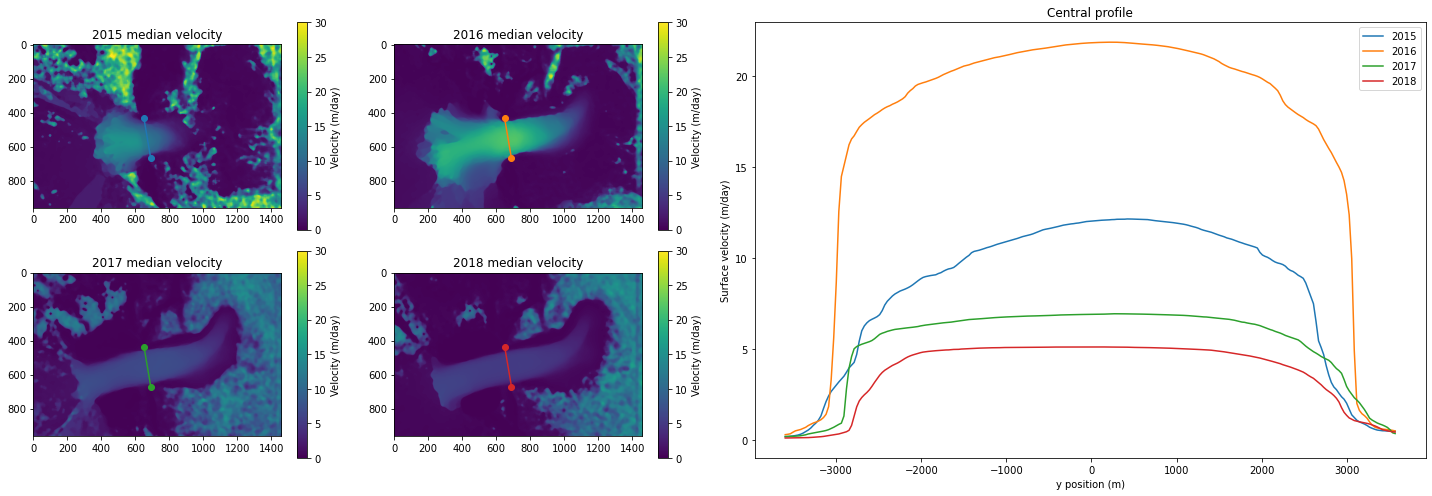

In [20]:
fig = plt.figure(figsize=(20,7))
gs = gridspec.GridSpec(2, 4)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Small subplots ---
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(img15_filt, vmin=0, vmax=30)
ax1.plot([x0, x1], [y0, y1], 'o-', color=colors[0])
ax1.set_title('2015 median velocity')
fig.colorbar(im1, ax=ax1, label='Velocity (m/day)')

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(img16_filt, vmin=0, vmax=30)
ax2.plot([x0, x1], [y0, y1], 'o-', color=colors[1])
ax2.set_title('2016 median velocity')
fig.colorbar(im2, ax=ax2, label='Velocity (m/day)')

ax3 = fig.add_subplot(gs[1, 0])
im3 = ax3.imshow(img17_filt, vmin=0, vmax=30)
ax3.plot([x0, x1], [y0, y1], 'o-', color=colors[2])
ax3.set_title('2017 median velocity')
fig.colorbar(im3, ax=ax3, label='Velocity (m/day)')

ax4 = fig.add_subplot(gs[1, 1])
im4 = ax4.imshow(img18_filt, vmin=0, vmax=30)
ax4.plot([x0, x1], [y0, y1], 'o-', color=colors[3])
ax4.set_title('2018 median velocity')
fig.colorbar(im4, ax=ax4, label='Velocity (m/day)')

ax_big = fig.add_subplot(gs[:, 2:])
ax_big.plot(y, u15)
ax_big.plot(y, u16)
ax_big.plot(y, u17)
ax_big.plot(y, u18)
ax_big.set_xlabel("y position (m)")
ax_big.set_ylabel('Surface velocity (m/day)')
ax_big.set_title('Central profile')
ax_big.legend(['2015','2016','2017','2018'])
plt.tight_layout()

if save_fig:
    plt.savefig(path_fig+'velocity_profiles.jpg',bbox_inches='tight', dpi=300)

# Complex model: invert n (stress exponent) & w (half-width)

## Run the inversion

In [130]:
# Choose velocity year to study and parameters
year = '2015'                                   # select year
U_VEC = u15                                     # select the velocity profile
U_0 = u0_15                                     # select the max velocity
ERR = np.ones((len(U_VEC))) #err15              # select error vector (variance profiles). To inverse without error, put ERR = np.ones((len(U_VEC)))
Y_VEC = y                                       # select the y vector

# Run the inversion
n_list = np.linspace(0,12,61).round(2)                                               # list of stress exponent
w_list = np.linspace(2100,3900,61)                                                  # list of half-width  85*30 - 145*30
RES = np.empty((len(w_list), len(n_list)))                                          # initialize residuals matrix
VR = np.empty((len(w_list), len(n_list)))                                           # initialize variance matrix
i = 0

for w in w_list:                                                                    # loop over the half-width
    U_DATA = U_VEC[np.where((Y_VEC >= -w) & (Y_VEC <= w))]                          # limit the real velocity profile to the same width modeled
    ERR_ = ERR[np.where((Y_VEC >= -w) & (Y_VEC <= w))]                              # limit the data error profile to the same width modeled
    if int(2*w/30) > len(U_DATA):                                                   # check if tested half-width is > (len(data) / 2)
        reduc_coef = ((int(2*w/30) - len(U_DATA))*30) / 2                           # estimate a reduction coefficient 
        Y_MODEL = np.linspace(-w+reduc_coef,w-reduc_coef,int(len(U_DATA)))          # define Y vector for modeled velocity with reduced length (remove the part out or range)   int(len(U_DATA))
    else:
        Y_MODEL = np.linspace(-w,w,int(len(U_DATA)))                                # define Y vector for modeled velocity
    j = 0
    for n in n_list:                                                                # loop over stress exponent
        U_MODEL = ice_velocity(U_0, Y_MODEL, w, n)                                  # calcul of the modeled velocity profile
        RES[i,j] = L2_norm_residuals(U_DATA,U_MODEL, ERR_)                          # estimate L2-norm resiudals btw real and modeled velocity
        j += 1
    i += 1

print(f'Min residual for {year}: {np.min(RES)}')

Min residual for 2015: 0.7205833890138602


## Residuals and best models

5% best models for year 2015 are n between 1.8 and 2.4 (best n = 2.0)
Uncertainty over n V1 (n_high - n_low) divided by 2 across n values: 0.3
Uncertainty over n V2 (same as V1 but use percentiles (16-84%)):     0.28


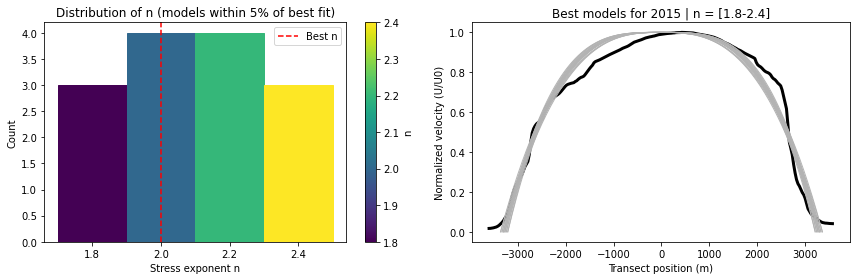

In [131]:
misfit = RES
min_misfit = np.min(misfit)
best_n_index = np.unravel_index(np.argmin(misfit), misfit.shape)[1]
best_n = n_list[best_n_index]

# Define a threshold for uncertainty (5% above the minimum misfit)
threshold = min_misfit * 1.05
#valid_n_indices = np.where(misfit <= threshold)[1]
valid_w_n_indices = np.where(misfit <= threshold)
valid_n_indices = np.where(misfit <= threshold)[1]
valid_n_indices.sort()
print(f'5% best models for year {year} are n between {n_list[valid_n_indices[0]]} and {n_list[valid_n_indices[-1]]} (best n = {best_n})')

unique_n, counts = np.unique(n_list[valid_n_indices], return_counts=True)

cmap = plt.cm.viridis
norm = plt.Normalize(unique_n.min(), unique_n.max())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
bars = plt.bar(unique_n, counts, width=(n_list[1]-n_list[0]))
for n_val, bar in zip(unique_n, bars):
    bar.set_color(cmap(norm(n_val)))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='n')
plt.xlabel('Stress exponent n')
plt.ylabel('Count')
plt.title('Distribution of n (models within 5% of best fit)')

plt.axvline(best_n, color='red', linestyle='--', label='Best n')
plt.xticks(unique_n)
plt.legend()


# Calculate uncertainty as the range of valid n values
uncertainty = (n_list[valid_n_indices[-1]] - n_list[valid_n_indices[0]]) / 2
n_low = np.percentile(n_list[valid_n_indices], 16)
n_high = np.percentile(n_list[valid_n_indices], 84)
uncertainty2 = (n_high - n_low)/2
print(f'Uncertainty over n V1 (n_high - n_low) divided by 2 across n values: {round(uncertainty,2)}')
print(f'Uncertainty over n V2 (same as V1 but use percentiles (16-84%)):     {round(uncertainty2,2)}')

plt.subplot(1,2,2)
plt.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')

for idx in range(len(valid_w_n_indices[0])):
    w = w_list[valid_w_n_indices[0][idx]]
    n = n_list[valid_w_n_indices[1][idx]]
    U_DATA = U_VEC[np.where((Y_VEC >= -w) & (Y_VEC <= w))]    # limit the real U profile to the same as modeled
    Y_MODEL = np.linspace(-w,w,int(len(U_DATA)))              # estimation of the y vector for modeled velocity
    U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, w, n)           # calcul of the modeled U

    plt.plot(Y_MODEL,U_BEST_MODEL/U_0, color=[0.7, 0.7, 0.7], linewidth=1, label='Modeled velocity (n={})'.format(str(round(best_n,1))))

plt.title(f'Best models for {year} | n = [{n_list[valid_n_indices[0]]}-{n_list[valid_n_indices[-1]]}]')
plt.xlabel('Transect position (m)')
plt.ylabel('Normalized velocity (U/U0)')
plt.tight_layout()
#plt.savefig(f'{path_fig}5perc_best_models/models_5perc_misfit_{year}.pdf',bbox_inches='tight')
plt.show()


## V2: test

5% best models for year 2015 are n between 1.6 and 2.8 (best n = 2.0)
Uncertainty over n V1 (n_high - n_low) divided by 2 across n values: 0.6
Uncertainty over n V2 (same as V1 but use percentiles (16-84%)):     0.4


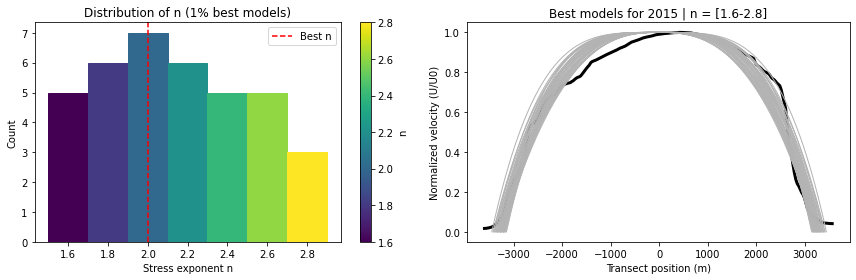

In [132]:
misfit = RES
min_misfit = np.min(misfit)
best_n_index = np.unravel_index(np.argmin(misfit), misfit.shape)[1]
best_n = n_list[best_n_index]

# Use 5% best models (smallest misfit)
a, b, idx_w, idx_n = prc_best_model(RES, w_list, n_list, prc = 1)
valid_w_n_indices = [idx_w, idx_n]
valid_n_indices = idx_n
valid_n_indices.sort()
print(f'5% best models for year {year} are n between {n_list[valid_n_indices[0]]} and {n_list[valid_n_indices[-1]]} (best n = {best_n})')

unique_n, counts = np.unique(n_list[valid_n_indices], return_counts=True)

cmap = plt.cm.viridis
norm = plt.Normalize(unique_n.min(), unique_n.max())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
bars = plt.bar(unique_n, counts, width=(n_list[1]-n_list[0]))
for n_val, bar in zip(unique_n, bars):
    bar.set_color(cmap(norm(n_val)))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='n')
plt.xlabel('Stress exponent n')
plt.ylabel('Count')
plt.title('Distribution of n (1% best models)')

plt.axvline(best_n, color='red', linestyle='--', label='Best n')
plt.xticks(unique_n)
plt.legend()


# Calculate uncertainty as the range of valid n values
uncertainty = (n_list[valid_n_indices[-1]] - n_list[valid_n_indices[0]]) / 2
n_low = np.percentile(n_list[valid_n_indices], 16)
n_high = np.percentile(n_list[valid_n_indices], 84)
uncertainty2 = (n_high - n_low)/2
print(f'Uncertainty over n V1 (n_high - n_low) divided by 2 across n values: {round(uncertainty,2)}')
print(f'Uncertainty over n V2 (same as V1 but use percentiles (16-84%)):     {round(uncertainty2,2)}')

plt.subplot(1,2,2)
plt.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')

for idx in range(len(valid_w_n_indices[0])):
    w = w_list[valid_w_n_indices[0][idx]]
    n = n_list[valid_w_n_indices[1][idx]]
    U_DATA = U_VEC[np.where((Y_VEC >= -w) & (Y_VEC <= w))]    # limit the real U profile to the same as modeled
    Y_MODEL = np.linspace(-w,w,int(len(U_DATA)))              # estimation of the y vector for modeled velocity
    U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, w, n)           # calcul of the modeled U

    plt.plot(Y_MODEL,U_BEST_MODEL/U_0, color=[0.7, 0.7, 0.7], linewidth=1, label='Modeled velocity (n={})'.format(str(round(best_n,1))))

plt.title(f'Best models for {year} | n = [{n_list[valid_n_indices[0]]}-{n_list[valid_n_indices[-1]]}]')
plt.xlabel('Transect position (m)')
plt.ylabel('Normalized velocity (U/U0)')
plt.tight_layout()
#plt.savefig(f'{path_fig}5perc_best_models/models_1perc_best_models_{year}.pdf',bbox_inches='tight')
plt.show()


Best parameter pair: n=2.00, w=3300 (misfit: 0.72)
Threshold used: 0.76


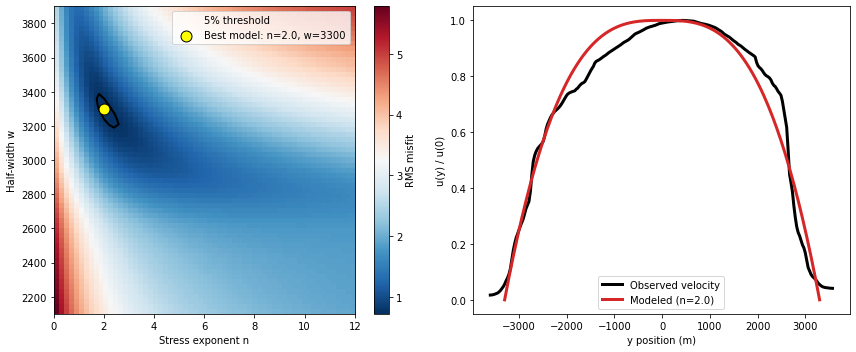

In [ ]:
# Find best model
min_misfit = np.min(RES)
idx_min = np.argwhere(RES == min_misfit)

best_w = w_list[idx_min[0,0]]
best_n = n_list[idx_min[0,1]]

# Define threshold (5% above min)
threshold = min_misfit * 1.05

# Create meshgrid for proper axes
N, W = np.meshgrid(n_list, w_list)

# --- Plot residuals ---
plt.figure(figsize=(12,5))
plt.subplot(121)
im = plt.imshow(RES, cmap='RdBu_r', origin='lower', extent=[n_list.min(), n_list.max(), w_list.min(), w_list.max()], aspect='auto')
CS = plt.contour(N, W, RES, levels=[threshold], colors='black', linewidths=2)
CS.collections[0].set_label('5% threshold')
plt.scatter(best_n, best_w, s=120, color='yellow', edgecolor='black', zorder=5, label=f'Best model: n={round(best_n,1)}, w={round(best_w)}')
plt.xlabel('Stress exponent n')
plt.ylabel('Half-width w')
plt.legend()
plt.colorbar(im, label='RMS misfit')

# --- Compute best model profile ---
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]
Y_MODEL = np.linspace(-best_w, best_w, len(U_DATA))
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)

# --- Plot velocity profile ---
plt.subplot(122)
plt.plot(Y_VEC, U_VEC/U_0, color='k', linewidth=3, label='Observed velocity')
plt.plot(Y_MODEL, U_BEST_MODEL/U_0, color='C3', linewidth=3, label=f'Modeled (n={round(best_n,1)})')
plt.xlabel('y position (m)')
plt.ylabel('u(y) / u(0)')
plt.legend()

# --- Print results ---
print(f'Best parameter pair: n={best_n:.2f}, w={round(best_w)} (misfit: {min_misfit:.2f})')
print(f'Threshold used: {threshold:.2f}')
#plt.savefig(f'{path_fig}5perc_best_models/models_5perc_misfit_space_{year}.pdf',bbox_inches='tight')
plt.tight_layout()

## Plot model of any n and w

Parameter pair: n=3 & w=3060


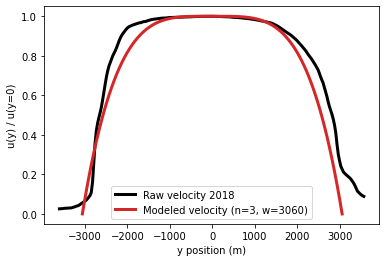

In [143]:
# Choose velocity year to study and parameters
year = '2018'                                   # select year
U_VEC = u18                                     # select the velocity profile
U_0 = u0_18                                     # select the max velocity
Y_VEC = y                                       # select the y vector

n = 3
w = 3060

U_DATA = U_VEC[np.where((Y_VEC >= -w) & (Y_VEC <= w))]                          # limit the real velocity profile to the same width modeled
if int(2*w/30) > len(U_DATA):                                                   # check if tested half-width is > (len(data) / 2)
    print('here')
    reduc_coef = ((int(2*w/30) - len(U_DATA))*30) / 2                           # estimate a reduction coefficient 
    Y_MODEL = np.linspace(-w+reduc_coef,w-reduc_coef,int(len(U_DATA)))          # define Y vector for modeled velocity with reduced length (remove the part out or range)   int(len(U_DATA))
else:
    Y_MODEL = np.linspace(-w,w,int(len(U_DATA)))                                # define Y vector for modeled velocity                                                             # loop over stress exponent
U_MODEL = ice_velocity(U_0, Y_MODEL, w, n)                                  # calcul of the modeled velocity profile

# Compute model
U_DATA = U_VEC[np.where((Y_VEC >= -w) & (Y_VEC <= w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-w,w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, w, n)           # calcul of the modeled U

# Plot best model
plt.figure()
plt.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label=f'Raw velocity {year}')
plt.plot(Y_MODEL,U_BEST_MODEL/U_0, color='C3', linewidth=3, label=f'Modeled velocity (n={round(n,1)}, w={round(w)})')
plt.legend()
plt.xlabel('y position (m)')
plt.ylabel('u(y) / u(y=0)')

model_save = U_BEST_MODEL
y_model_save = Y_MODEL
y_data_save = Y_VEC
param = [n, U_0, w, np.min(RES)]
print(f'Parameter pair: n={param[0]} & w={round(param[2])}')
plt.savefig(f'{path_fig}model_{year}_n{n}_w{w}.pdf',bbox_inches='tight')

Best parameter pair: n=4.800000000000001 & w=3060 (misfit:0.28 m/day)
5% best models: n[2.8000000000000003-9.200000000000001]


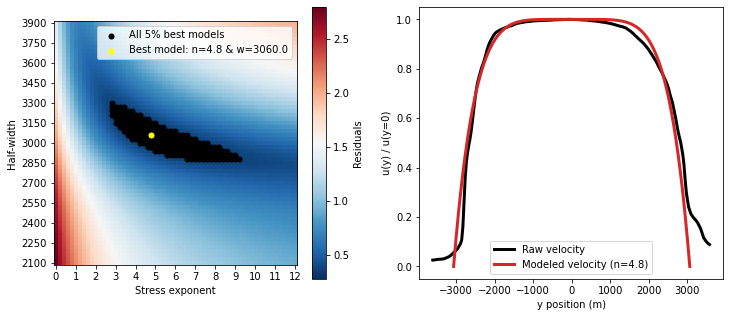

In [38]:
# Find best 5% models + THE best model
a, b, idx_w, idx_n = prc_best_model(RES, w_list, n_list, prc = 5)   # find 5% best models
idx_min = np.argwhere(RES == np.min(RES))                           # find index of the parameters that give the best model

best_w = w_list[np.argwhere(RES == np.min(RES))[0,0]]                                       # find best half-width w
best_n = n_list[np.argwhere(RES == np.min(RES))[0,1]]                                       # find best stress exponent n

# Plot residuals
plt.figure(figsize=(12,5))
plt.subplot(121)
im = plt.imshow(RES, cmap = 'RdBu_r', origin='lower') #RdBu_r
#plt.scatter(idx_min[:,1], idx_min[:,0], s = 100, color='black', marker='.', label='All 5% best models')
plt.scatter(idx_n, idx_w, s = 100, color='black', marker='.', label='All 5% best models')
plt.scatter(np.argwhere(RES == np.min(RES))[0,1],np.argwhere(RES == np.min(RES))[0,0], s=100, color='yellow', marker='.', label='Best model: n='+str(round(best_n,1))+' & w='+str(best_w))
#plt.clim(0,1)

# Parametrize imagesc plot
n_x = n_list.shape[0]
w_y = w_list.shape[0]
n_list_r = [round(n) for n in n_list]
w_list_r = [round(w) for w in w_list]
no_labels = 12                                                      # how many labels to see on axis x
step_x = int(n_x / (no_labels - 1))                                 # step between consecutive labels
step_y = int(w_y / (no_labels - 1))                                 # step between consecutive labels
x_positions = np.arange(0,n_x,step_x)                               # pixel count at label position
y_positions = np.arange(0,w_y,step_y)                               # pixel count at label position
x_labels = n_list_r[::step_x]                                       # labels you want to see
y_labels = w_list_r[::step_y]                                       # labels you want to see
plt.xticks(x_positions, x_labels)
plt.yticks(y_positions, y_labels)
plt.xlabel('Stress exponent')
plt.ylabel('Half-width')
plt.legend()
plt.colorbar(im, label='Residuals')

# Compute best model
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-best_w,best_w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)           # calcul of the modeled U

# Plot best model
plt.subplot(122)
plt.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')
plt.plot(Y_MODEL,U_BEST_MODEL/U_0, color='C3', linewidth=3, label='Modeled velocity (n={})'.format(str(round(best_n,1))))
plt.legend()
plt.xlabel('y position (m)')
plt.ylabel('u(y) / u(y=0)')

model_save = U_BEST_MODEL
y_model_save = Y_MODEL
y_data_save = Y_VEC
param = [best_n, U_0, best_w, np.min(RES)]
print(f'Best parameter pair: n={param[0]} & w={round(param[2])} (misfit:{round(param[3],2)} m/day)')
print(f'5% best models: n[{np.min(n_list[idx_n])}-{np.max(n_list[idx_n])}]')

# path_save = f'/Users/mouchonc/Documents/RESEARCH/IceRheology/figures/models/5perc_best_models/'
# plt.savefig(path_save+f'figures/5perc_best_model_n{str(round(best_n,1))}_{year}.pdf',bbox_inches='tight', dpi=300)

## Residualsd and best model for edges focus

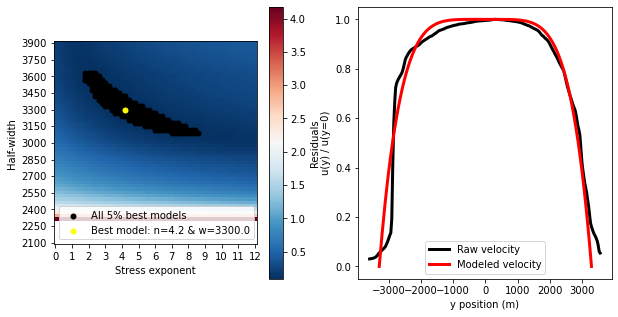

In [70]:
# Find best 5% models + THE best model
a, b, idx_w, idx_n = prc_best_model(RES_edges, w_list, n_list, prc = 5)   # find 5% best models
idx_min = np.argwhere(RES_edges == np.nanmin(RES_edges))                           # find index of the parameters that give the best model
best_w = w_list[idx_min[0,0]]                                       # find best half-width w
best_n = n_list[idx_min[0,1]]                                       # find best stress exponent n

# Plot residuals
plt.figure(figsize=(10,5))
plt.subplot(121)
im = plt.imshow(RES_edges, cmap = 'RdBu_r', origin='lower')
plt.scatter(idx_n, idx_w, s = 100, color='black', marker='.', label='All 5% best models')
plt.scatter(idx_min[0,1],idx_min[0,0], s=100, color='yellow', marker='.', label='Best model: n='+str(round(best_n,1))+' & w='+str(best_w))

# Parametrize imagesc plot
n_x = n_list.shape[0]
w_y = w_list.shape[0]
n_list_r = [round(n) for n in n_list]
w_list_r = [round(w) for w in w_list]
no_labels = 12                                                      # how many labels to see on axis x
step_x = int(n_x / (no_labels - 1))                                 # step between consecutive labels
step_y = int(w_y / (no_labels - 1))                                 # step between consecutive labels
x_positions = np.arange(0,n_x,step_x)                               # pixel count at label position
y_positions = np.arange(0,w_y,step_y)                               # pixel count at label position
x_labels = n_list_r[::step_x]                                       # labels you want to see
y_labels = w_list_r[::step_y]                                       # labels you want to see
plt.xticks(x_positions, x_labels)
plt.yticks(y_positions, y_labels)
plt.xlabel('Stress exponent')
plt.ylabel('Half-width')
plt.legend()
plt.colorbar(im, label='Residuals')

# Compute best model
#best_n = 2.5
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-best_w,best_w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)           # calcul of the modeled U

# Plot best model
plt.subplot(122)
plt.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')
plt.plot(Y_MODEL,U_BEST_MODEL/U_0, color='red', linewidth=3, label='Modeled velocity')
plt.legend()
plt.xlabel('y position (m)')
plt.ylabel('u(y) / u(y=0)')

if save_fig:
    plt.savefig(path_fig+'results_inv_n_and_w_2018.jpg',bbox_inches='tight', dpi=300)

## Residuals and best model for center focus

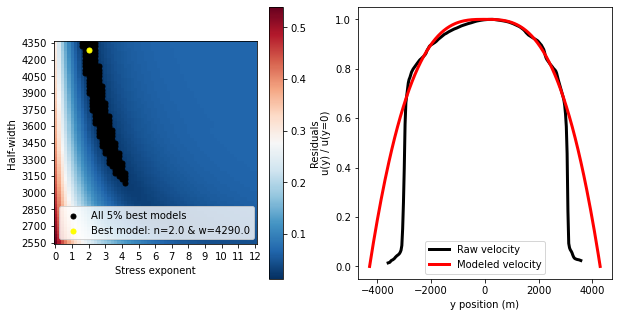

In [16]:
# Find best 5% models + THE best model
a, b, idx_w, idx_n = prc_best_model(RES_center, w_list, n_list, prc = 5)   # find 5% best models
idx_min = np.argwhere(RES_center == np.min(RES_center))                           # find index of the parameters that give the best model
best_w = w_list[idx_min[0,0]]                                       # find best half-width w
best_n = n_list[idx_min[0,1]]                                       # find best stress exponent n

# Plot residuals
plt.figure(figsize=(10,5))
plt.subplot(121)
im = plt.imshow(RES_center, cmap = 'RdBu_r', origin='lower')
plt.scatter(idx_n, idx_w, s = 100, color='black', marker='.', label='All 5% best models')
plt.scatter(idx_min[0,1],idx_min[0,0], s=100, color='yellow', marker='.', label='Best model: n='+str(round(best_n,1))+' & w='+str(best_w))

# Parametrize imagesc plot
n_x = n_list.shape[0]
w_y = w_list.shape[0]
n_list_r = [round(n) for n in n_list]
w_list_r = [round(w) for w in w_list]
no_labels = 12                                                      # how many labels to see on axis x
step_x = int(n_x / (no_labels - 1))                                 # step between consecutive labels
step_y = int(w_y / (no_labels - 1))                                 # step between consecutive labels
x_positions = np.arange(0,n_x,step_x)                               # pixel count at label position
y_positions = np.arange(0,w_y,step_y)                               # pixel count at label position
x_labels = n_list_r[::step_x]                                       # labels you want to see
y_labels = w_list_r[::step_y]                                       # labels you want to see
plt.xticks(x_positions, x_labels)
plt.yticks(y_positions, y_labels)
plt.xlabel('Stress exponent')
plt.ylabel('Half-width')
plt.legend()
plt.colorbar(im, label='Residuals')

# Compute best model
#best_n = 2.5
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-best_w,best_w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)           # calcul of the modeled U

# Plot best model
plt.subplot(122)
plt.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')
plt.plot(Y_MODEL,U_BEST_MODEL/U_0, color='red', linewidth=3, label='Modeled velocity')
plt.legend()
plt.xlabel('y position (m)')
plt.ylabel('u(y) / u(y=0)')

if save_fig:
    plt.savefig(path_fig+'results_inv_n_and_w_2018.jpg',bbox_inches='tight', dpi=300)

## Strain and models for 2016

Text(0, 0.5, 'Strain')

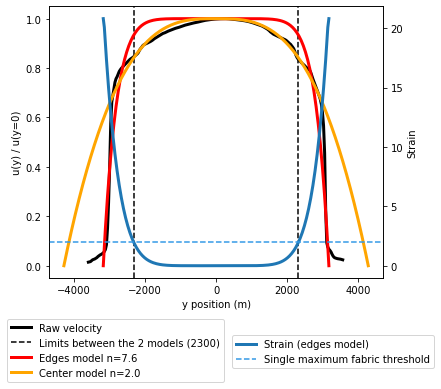

In [17]:
idx_min = np.argwhere(RES_edges == np.nanmin(RES_edges))
best_n = n_list[idx_min[0,1]]
best_w = w_list[idx_min[0,0]]
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-best_w,best_w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)           # calcul of the modeled U
strain = np.gradient(U_BEST_MODEL)/np.gradient(Y_MODEL)*365

# Plot best model
fig, ax1 = plt.subplots(figsize=(6, 5))
ax2 = ax1.twinx()
ax1.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')
ax1.axvline(-2300,0,1, color='k', linestyle="--", label='Limits between the 2 models (2300)')
ax1.axvline(2300,0,1, color='k', linestyle="--")
ax1.plot(Y_MODEL,U_BEST_MODEL/U_0, color='red', linewidth=3, label='Edges model n={}'.format(np.round(best_n,2)))
ax2.plot(Y_MODEL,abs(strain), linewidth=3, label='Strain (edges model)')
ax2.axhline(2, color="#3399e6", linestyle='--', label='Single maximum fabric threshold')

idx_min = np.argwhere(RES_center == np.nanmin(RES_center))
best_n = n_list[idx_min[0,1]]
best_w = w_list[idx_min[0,0]]
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-best_w,best_w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)           # calcul of the modeled U

ax1.plot(Y_MODEL,U_BEST_MODEL/U_0, color='orange', linewidth=3, label='Center model n={}'.format(np.round(best_n,2)))



ax1.legend(loc='lower center', bbox_to_anchor=(0.20,-0.4))
ax2.legend(loc='lower center', bbox_to_anchor=(0.85,-0.35))
ax1.set_xlabel('y position (m)')
ax1.set_ylabel('u(y) / u(y=0)')
ax2.set_ylabel('Strain')

## Fabric threshold 2016

Text(0, 0.5, 'Strain')

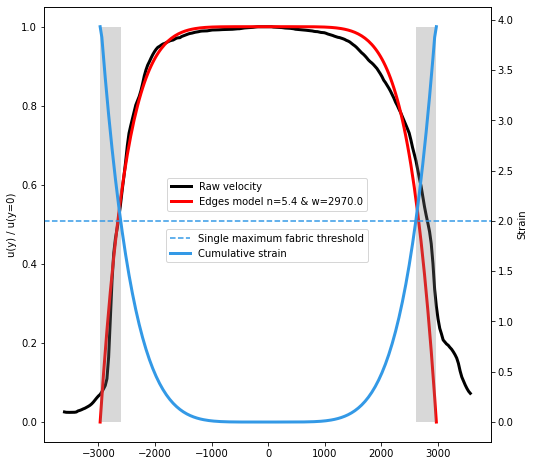

In [172]:
idx_min = np.argwhere(RES == np.min(RES))
best_n = n_list[idx_min[0,1]]
best_w = w_list[idx_min[0,0]]
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]                              # limit the real U profile to the same as modeled
Y_MODEL = np.linspace(-best_w,best_w,int(len(U_DATA)))                # estimation of the y vector for modeled velocity
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)           # calcul of the modeled U
strain = np.gradient(U_BEST_MODEL)/np.gradient(Y_MODEL)*365

cvelocity = 'red' #"#69b3a2"
cstrain = "#3399e6"
# Plot best model
fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()
ax2.axhline(2, color="#3399e6", linestyle='--', label='Single maximum fabric threshold')
ax2.fill_between(Y_MODEL, np.max(abs(strain)), where=np.abs(strain) > 2, facecolor='grey', alpha=.3)
ax1.plot(Y_VEC,U_VEC/U_0, color='k', linewidth=3, label='Raw velocity')
ax1.plot(Y_MODEL,U_BEST_MODEL/U_0, color=cvelocity, linewidth=3, label='Edges model n={} & w={}'.format(np.round(best_n,2), best_w))
ax2.plot(Y_MODEL, np.abs(strain), color=cstrain, linewidth=3,label='Cumulative strain')

ax1.legend(loc='lower center', bbox_to_anchor=(0.5,0.52))
ax2.legend(loc='upper center', bbox_to_anchor=(0.5,0.5))
ax2.set_xlabel('y position (m)')
ax1.set_ylabel('u(y) / u(y=0)',)
ax2.set_ylabel('Strain')
